# Lecture 10: AgentOps

실제 서비스 운영을 위해 지표를 설정합니다.

Pytest를 이용해 의도적인 검증 에러를 발생시키고, 이를 LangSmith 대시보드에서 분석하는 전체 파이프라인을 실습합니다.



## Pytest와 자동화
**Pytest**는 파이썬의 단위 테스트를 자동화하는 도구입니다.<br> 우리는 이를 이용해 에이전트의 응답을 자동으로 검사하고, 그 결과를 **LangSmith**에서 시각적으로 모니터링할 것입니다.

## 환경 설정

- 실습 환경 구축을 위한 패키지 설치 (설치 후 세션을 다시 시작해야합니다.)

In [1]:
!pip install langgraph langchain-upstage langchain==1.1.3 \
     rich tavily-python  langchain-text-splitters langchain_classic \
     qdrant_client langchain_qdrant langsmith langchain_tavily pytest \
     python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.2/102.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.2/377.2 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.8/295.8 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 18.1 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: langchain
    Found existing installation: langchain 1.2.3
    Uninstalling langchain-1.2.3:
      Successfully uninstalled langchain-1.2.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 4.57

- Google Colab의 '보안 비밀번호(Secrets)' 메뉴에 등록한 API KEY를 환경 변수로 불러옵니다.

In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()

# 설정할 키 목록
keys = [
    'LANGSMITH_API_KEY', 'UPSTAGE_API_KEY', 'TAVILY_API_KEY'
]

for key in keys:
    value = os.getenv(key)
    if value is None:
        print(f"경고: {key}를 .env에서 찾을 수 없습니다.")
    else:
        os.environ[key] = value

# 고정값 설정
os.environ["LANGSMITH_TRACING_V2"] = 'true'
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGSMITH_PROJECT"] = 'agentic-workflow'

- Langsmith에 기록될 데이터셋 이름

In [3]:
os.environ["LANGSMITH_TEST_SUITE"]="eval_rag_agents_companion_v2"

### 문서 준비
- 이전 5강 실습에서 다룬 Indexing 관련 코드를 사용합니다.
- 사용할 문서: [AgentOps & Eval에 관한 구글 백서](https://www.kaggle.com/whitepaper-agent-companion)

In [4]:
# https://drive.google.com/file/d/1GVPdwEh48bErTNdhxD0vqxPAifSx1I6Y/view - d/ 와 /view 사이에 있는 아이디 값을 사용합니다.
!gdown --id 1GVPdwEh48bErTNdhxD0vqxPAifSx1I6Y -O Agents_Companion_v2.pdf

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1GVPdwEh48bErTNdhxD0vqxPAifSx1I6Y
To: /content/Agents_Companion_v2.pdf
100% 11.1M/11.1M [00:00<00:00, 26.2MB/s]


In [5]:
# ==============================
#            IMPORTS
# ==============================

from pydantic import BaseModel, Field, field_validator
from langchain.agents import create_agent
from langgraph.graph import add_messages, StateGraph, START, END
from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict
from typing import Annotated, List, Literal
from langchain_core.documents import Document
from langchain_classic.embeddings import CacheBackedEmbeddings
from langchain_classic.storage import LocalFileStore
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams
from langchain_qdrant import QdrantVectorStore
from langchain.chat_models import init_chat_model
from langchain_upstage import UpstageEmbeddings

# 함수 밖에서 클라이언트 변수를 미리 선언 (최초 1회만 생성하게 함)
_global_qdrant_client = None

/usr/local/lib/python3.12/dist-packages/langchain_tavily/tavily_research.py:97: UserWarning: Field name "output_schema" in "TavilyResearch" shadows an attribute in parent "BaseTool"
  class TavilyResearch(BaseTool):  # type: ignore[override, override]
/usr/local/lib/python3.12/dist-packages/langchain_tavily/tavily_research.py:97: UserWarning: Field name "stream" in "TavilyResearch" shadows an attribute in parent "BaseTool"
  class TavilyResearch(BaseTool):  # type: ignore[override, override]


In [6]:
# ==============================
#    Qdrant/Vectorstore SETUP
# ==============================

def load_and_split_pdf(file_path: str) -> List[Document]:
    """PDF를 로드하고 청크로 분할합니다."""
    from langchain_upstage import UpstageDocumentParseLoader
    from langchain_text_splitters import RecursiveCharacterTextSplitter

    print(f"📄 PDF 로드 중: {file_path}")

    loader = UpstageDocumentParseLoader(
        file_path,
        output_format="markdown",
        ocr="force",
        coordinates=False
    )
    raw_pages = loader.load()

    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=200,
        add_start_index=True,
    )
    splits = text_splitter.split_documents(raw_pages)
    print(f"✅ {len(splits)}개의 청크로 분할 완료")
    return splits


def setup_vectorstore(
    underlying_embeddings,
    collection_name,
    documents=None,
):
    """Qdrant 벡터스토어를 생성하고 채웁니다."""
    global _global_qdrant_client

    if _global_qdrant_client is None:
        _global_qdrant_client = QdrantClient(path="./qdrant_db")

    qdrant_client = _global_qdrant_client

    # 캐시 스토어 생성
    store = LocalFileStore("./cache/")

    # CacheBackedEmbeddings로 감싸서 캐싱 활성화
    # 여러번 시행할 경우 캐시 활용 (비용 절약)
    embeddings = CacheBackedEmbeddings.from_bytes_store(
        underlying_embeddings,
        store,
        namespace=underlying_embeddings.model,
    )

    # 컬렉션이 이미 존재하는지 확인
    if not qdrant_client.collection_exists(collection_name):
        print(f"📦 새로운 컬렉션 생성 중: {collection_name}")
        _global_qdrant_client.create_collection(
            collection_name=collection_name,
            vectors_config=VectorParams(
                size=4096,
                distance=Distance.COSINE),
        )

    # VectorStore
    vectorstore = QdrantVectorStore(
        client=qdrant_client,
        collection_name=collection_name,
        embedding=embeddings,
    )

    # documents가 제공된 경우에만 추가
    if documents:
        vectorstore.add_documents(documents)
        print(f"✅ {len(documents)}개의 문서가 추가되었습니다.")
    else:
        print(f"ℹ️ 기존 벡터스토어를 로드했습니다 (추가 문서 없음).")

    return vectorstore

def get_or_create_vectorstore(
    underlying_embeddings,
    collection_name: str,
    pdf_path: str = "Agents_Companion_v2.pdf"
):
    """벡터스토어를 가져오거나 생성합니다. 문서가 없으면 PDF를 로드합니다."""
    global _global_qdrant_client

    if _global_qdrant_client is None:
        print("🚀 Qdrant 클라이언트를 새로 초기화합니다.")
        _global_qdrant_client = QdrantClient(path="./qdrant_db")

    # 문서가 필요한지 확인
    doc_splits = None

    if _global_qdrant_client.collection_exists(collection_name):
        points_count = _global_qdrant_client.get_collection(collection_name).points_count
        if points_count == 0:
            print("📭 컬렉션이 비어있습니다. PDF를 로드합니다...")
            doc_splits = load_and_split_pdf(pdf_path)
        else:
            print(f"✅ 기존 벡터스토어 사용 ({points_count}개 문서)")
    else:
        print("🆕 새 컬렉션을 생성합니다. PDF를 로드합니다...")
        doc_splits = load_and_split_pdf(pdf_path)

    return setup_vectorstore(
        underlying_embeddings=underlying_embeddings,
        collection_name=collection_name,
        documents=doc_splits
    )

In [7]:
# ==============================
#     임베딩/벡터스토어 준비
# ==============================
underlying_embeddings = UpstageEmbeddings(
    model="solar-embedding-1-large"
)

vectorstore = get_or_create_vectorstore(
    underlying_embeddings=underlying_embeddings,
    collection_name="solar-embedding-1-large",
    pdf_path="Agents_Companion_v2.pdf"
)

🚀 Qdrant 클라이언트를 새로 초기화합니다.
🆕 새 컬렉션을 생성합니다. PDF를 로드합니다...
📄 PDF 로드 중: Agents_Companion_v2.pdf
✅ 134개의 청크로 분할 완료
📦 새로운 컬렉션 생성 중: solar-embedding-1-large


/usr/local/lib/python3.12/dist-packages/langchain_classic/embeddings/cache.py:58: UserWarning: Using default key encoder: SHA-1 is *not* collision-resistant. While acceptable for most cache scenarios, a motivated attacker can craft two different payloads that map to the same cache key. If that risk matters in your environment, supply a stronger encoder (e.g. SHA-256 or BLAKE2) via the `key_encoder` argument. If you change the key encoder, consider also creating a new cache, to avoid (the potential for) collisions with existing keys.
  _warn_about_sha1_encoder()


✅ 134개의 문서가 추가되었습니다.


## Task 소개


### Task 1. 불필요한 도구 호출 방지 (Off-topic)
에이전트가 업무와 무관한 질문(예: "오늘 점심 뭐 먹지?")에 대해 불필요하게 도구를 호출하여 비용을 발생시키는지 확인합니다.

* **평가 방식**: AI의 첫 번째 응답을 가로채어 `tool_calls` 리스트가 비어있는지 확인합니다.
* **목적**: 불필요한 API 호출 비용 및 지연 시간 방지.



``` python

# --- [Test 1] Off-topic 억제 테스트 ---
@pytest.mark.langsmith
@pytest.mark.parametrize(
    "query",
    [
        "오늘 점심 뭐 먹지?", # 1
        "안녕하세요!",        # 2
        "최근 본 영화 추천해줘" # 3
    ],
)
def test_no_tools_on_offtopic_query(query: str) -> None:
    """에이전트가 업무와 무관한 질문에 도구를 호출하지 않는지 테스트합니다."""
    # LangSmith에 입력 및 기대 결과 로깅
    t.log_inputs({"query": query})
    expected_tool_calls = [] # 도구 호출이 없어야 함
    t.log_reference_outputs({"tool_calls": expected_tool_calls})

    # 에이전트 실행
    # create_react_agent로 생성된 그래프는 전체를 실행하여 도구 호출 여부를 확인합니다.
    result = agentic_rag.invoke({"messages": [("user", query)]})

    # 모델의 첫 번째 응답(ai_message)에서 tool_calls 추출
    # result["messages"]의 0번은 유저 메시지, 1번이 모델의 첫 응답입니다.
    ai_message = result["messages"][1]
    actual_tool_calls = getattr(ai_message, "tool_calls", [])

    # 결과 로깅 및 검증
    t.log_outputs({"tool_calls": actual_tool_calls})

    # 도구 호출 리스트가 비어있는지 확인
    assert len(actual_tool_calls) == 0, f"에이전트가 '{query}' 질문에 도구를 호출했습니다: {actual_tool_calls}"

```

## Task 2. 검색 쿼리의 적절성 테스트
에이전트가 질문의 의도를 파악하고, 리트리버(검색 도구)에 전달할 **핵심 키워드**를 제대로 생성했는지 확인합니다.

* **평가 방식**: 생성된 검색 쿼리 안에 반드시 포함되어야 할 단어(예: "Observability")가 있는지 검사합니다.
* **목적**: 검색 단계에서의 정보 누락 방지.

```python
# --- [Test 2] 검색 쿼리 정확도 테스트 ---
@pytest.mark.langsmith
@pytest.mark.parametrize(
    "query,expected_keyword",
    [
        ("AgentOps의 Observability에 대해 설명해줘", "Observability"), # 4
        ("LangGraph에서 StateGraph 사용법 알려줘", "StateGraph"), # 5
        ("에이전트의 메모리 관리 방법은?", "메모리"), # 6
    ],
)
def test_searches_with_correct_query(query: str, expected_keyword: str) -> None:
    """에이전트가 질문에 맞는 검색 쿼리를 생성하여 리트리버 도구를 호출하는지 테스트합니다."""

    # 테스트 입력 및 기대 키워드 정의
    t.log_inputs({"query": query})
    t.log_reference_outputs({"expected_keyword": expected_keyword})

    # 에이전트 실행 (create_react_agent 기반)
    # result["messages"]의 1번 인덱스가 모델의 첫 번째 응답(AI Message)입니다.
    result = agentic_rag.invoke({"messages": [("user", query)]})

    # 모델의 응답에서 도구 호출 정보 추출
    ai_message = result["messages"][1]
    tool_calls = getattr(ai_message, "tool_calls", [])

    actual_search_query = None
    # 리트리버 도구가 호출되었는지 확인하고 인자(query) 추출
    if tool_calls and tool_calls[0]["name"] == "agentops_retriever_tool":
        actual_search_query = tool_calls[0]["args"].get("query", "")

    t.log_outputs({"actual_search_query": actual_search_query})

    # 검증: 도구가 호출되었는지와 쿼리에 핵심 키워드가 포함되었는지 확인
    assert actual_search_query is not None, "에이전트가 리트리버 도구를 호출하지 않았습니다."
    assert expected_keyword.lower() in actual_search_query.lower(), (
        f"검색 쿼리 '{actual_search_query}'에 기대 키워드 '{expected_keyword}'가 포함되어 있지 않습니다."
    )
```

## Task 3. 복잡한 도구 호출 (Multi-tool Usage)
내부 문서 검색과 외부 웹 검색이 모두 필요한 복잡한 질문을 에이전트가 어떻게 처리하는지 평가합니다.

* **평가 방식**:
    1.  **효율성**: 정답을 내기까지 발생한 대화의 턴(Turn) 수를 측정합니다.
    2.  **조합 능력**: 두 가지 도구(내부/외부)를 모두 호출했는지 체크합니다.
    3.  **충분성**: 최종 답변의 길이가 너무 짧지는 않은지 검사합니다.


```python

# --- [Test 3] 도구 조합(Multi-tool) 테스트 ---
@pytest.mark.langsmith
@pytest.mark.parametrize(
    "query",
    [
        "우리 백서에 정의된 AgentOps Observability의 3대 요소를 설명하고,\
    2025년 현재 업계에서 추가로 논의되는 최신 트렌드를 웹에서 찾아 비교해줘.", # 7
        "LangGraph의 StateGraph 개념을 백서에서 찾고, \
    최신 LangGraph 릴리즈 노트를 웹에서 검색해서 변경사항을 알려줘.", # 8
    ],
)
def test_uses_multiple_tools_for_complex_query(query: str) -> None:
    """내부 문서와 외부 웹 검색이 모두 필요한 복잡한 질문에 대해 도구들을 잘 활용하는지 테스트합니다."""

    # 내부/외부 정보가 모두 필요할 법한 복잡한 질문 설정
    t.log_inputs({"query": query})

    result = agentic_rag.invoke({"messages": [("user", query)]})

    # 전체 실행 과정에서 호출된 모든 도구 이름 추출
    tool_calls = [
        tc["name"]
        for msg in result["messages"]
        for tc in getattr(msg, "tool_calls", [])
    ]

    # 실행 단계(메시지 수) 기록: 에이전트가 정답을 내기까지의 효율성을 측정
    t.log_feedback(key="num_steps", score=len(result["messages"]))

    # 검증: 내부 리트리버와 웹 검색 도구가 모두 한 번 이상 사용되었는지 확인
    assert "agentops_retriever_tool" in tool_calls, "내부 문서 검색 도구가 호출되지 않았습니다."
    assert any("search" in name.lower() for name in tool_calls), "웹 검색 도구가 호출되지 않았습니다."

    # 최종 응답 확인 및 로깅
    last_message = result["messages"][-1]
    t.log_outputs({"final_response": last_message.content})

    assert len(last_message.content) > 100, "최종 답변이 충분한 정보를 포함하고 있지 않습니다."
```

#### Task 4. 근거성(Groundedness) 평가
가장 중요한 **근거성(Groundedness)** 평가입니다. 에이전트의 답변이 검색된 문서(내부+외부) 내용에만 기반하고 있는지 다른 LLM을 통해 채점합니다.

* **평가 방식**: 판사 LLM이 답변과 검색 문서를 비교하여 True/False를 반환하고, 이를 LangSmith의 피드백 점수로 기록합니다.
* **특이사항**: 웹 검색 결과와 내부 문서를 합쳐서 레퍼런스로 사용합니다.

```python
class GroundednessGrade(BaseModel):
    score: bool = Field(description="답변이 검색된 문서 내용에만 기반하고 있으면 True, 아니면 False")

judge_llm = llm.with_structured_output(GroundednessGrade)
```

```python
# --- [Test 4] 답변 근거성(Groundedness) 테스트 ---
@pytest.mark.langsmith
@pytest.mark.parametrize(
    "query",
    [
        "AgentOps 백서에서 설명하는 에이전트 평가 방법론의 핵심은 무엇인가요?", # 9
        "백서에 따르면 에이전트 아키텍처의 주요 구성 요소는 무엇인가요?", # 10
    ],
)
def test_grounded_in_source_info(query: str) -> None:
    """에이전트의 답변이 실제 검색된 도구 결과에 근거하는지 테스트합니다."""

    t.log_inputs({"query": query})

    # 에이전트 실행
    result = agentic_rag.invoke({"messages": [("user", query)]})

    # 도구(리트리버 및 웹검색) 호출 결과 합치기
    tool_outputs = "\n\n".join(
        msg.content
        for msg in result["messages"]
        if msg.type == "tool"
    )

    final_answer = result["messages"][-1].content

    t.log_outputs({
        "response": final_answer,
        "source_documents": tool_outputs,
    })

    # 판사 모델(Judge LLM)을 통한 근거성 채점
    # t.trace_feedback을 사용하면 LangSmith 대시보드에 채점 과정이 별도의 트레이스로 남습니다.
    with t.trace_feedback():
        instructions = (
            "Grade the following ANSWER. "
            "The ANSWER should be fully grounded in (i.e. supported by) the source DOCUMENTS. "
            "If the ANSWER contains information NOT present in the DOCUMENTS, return False. "
            "Otherwise, return True."
        )

        answer_and_docs = (
            f"ANSWER: {final_answer}\n"
            f"DOCUMENTS:\n{tool_outputs}"
        )

        # 판사 모델 호출
        grade = judge_llm.invoke([
            {"role": "system", "content": instructions},
            {"role": "user", "content": answer_and_docs},
        ])

        # LangSmith에 채점 결과 기록
        t.log_feedback(key="groundedness", score=grade.score)

    # 최종 검증
    assert grade.score, f"답변이 검색된 문서에 근거하지 않습니다: {final_answer}"
```

## pytest 진행
- **pytest**: 파이썬 코드를 검증, 유닛 테스트부터 복잡한 기능 테스트까지 자동화 가능한 프레임워크

#### 실행 중인 Qdrant의 클라이언트 닫기
- Qdrant는 레이스 컨디션을 원천 차단하기 위해 "한 번에 한 프로세스만 갖는다."라는 원칙을 갖습니다.

> **Race Condition(경쟁 상태)이란?**
> 공유 자원에 여러 프로세스가 동시에 접근하여 데이터의 일관성이 깨지는 현상을 말합니다. Qdrant는 데이터 보호를 위해 한 번에 하나의 프로세스 점유를 권장하므로, 에러 방지를 위해 클라이언트를 안전하게 종료 후 다시 시작합니다.

In [8]:
if hasattr(vectorstore, "client"):
    vectorstore.client.close()
    print("✅ vectorstore 내부의 클라이언트가 성공적으로 해제되었습니다.")

✅ vectorstore 내부의 클라이언트가 성공적으로 해제되었습니다.


#### pytest를 위한 별도의 파이썬 파일 작성

In [9]:
%%writefile evaluate_react.py
# ==============================
#            IMPORTS
# ==============================

import pytest
from langsmith import testing as t
from pydantic import BaseModel, Field, field_validator
from langchain.agents import create_agent
from langgraph.graph import add_messages
from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict
from typing import Annotated, List, Literal
from langchain_core.documents import Document
from langchain_classic.embeddings import CacheBackedEmbeddings
from langchain_classic.storage import LocalFileStore
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams
from langchain_qdrant import QdrantVectorStore
from langchain.chat_models import init_chat_model
from langchain_upstage import UpstageEmbeddings

# ==============================
#         환경설정 및 모델
# ==============================

MODEL = "solar-pro2"
llm = init_chat_model(
    model=MODEL,
    temperature=0.
)

# ==============================
#    Qdrant/Vectorstore SETUP
# ==============================

# 함수 밖에서 클라이언트 변수를 미리 선언 (최초 1회만 생성하게 함)
_global_qdrant_client = None


def load_and_split_pdf(file_path: str) -> List[Document]:
    """PDF를 로드하고 청크로 분할합니다."""
    from langchain_upstage import UpstageDocumentParseLoader
    from langchain_text_splitters import RecursiveCharacterTextSplitter

    print(f"📄 PDF 로드 중: {file_path}")

    loader = UpstageDocumentParseLoader(
        file_path,
        output_format="markdown",
        ocr="force",
        coordinates=False
    )
    raw_pages = loader.load()

    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=200,
        add_start_index=True,
    )
    splits = text_splitter.split_documents(raw_pages)
    print(f"✅ {len(splits)}개의 청크로 분할 완료")
    return splits


def setup_vectorstore(
    underlying_embeddings,
    collection_name,
    documents=None,
):
    """Qdrant 벡터스토어를 생성하고 채웁니다."""
    global _global_qdrant_client

    if _global_qdrant_client is None:
        _global_qdrant_client = QdrantClient(path="./qdrant_db")

    qdrant_client = _global_qdrant_client

    # 캐시 스토어 생성
    store = LocalFileStore("./cache/")

    # CacheBackedEmbeddings로 감싸서 캐싱 활성화
    # 여러번 시행할 경우 캐시 활용 (비용 절약)
    embeddings = CacheBackedEmbeddings.from_bytes_store(
        underlying_embeddings,
        store,
        namespace=underlying_embeddings.model,
    )

    # 컬렉션이 이미 존재하는지 확인
    if not qdrant_client.collection_exists(collection_name):
        print(f"📦 새로운 컬렉션 생성 중: {collection_name}")
        _global_qdrant_client.create_collection(
            collection_name=collection_name,
            vectors_config=VectorParams(
                size=4096,
                distance=Distance.COSINE),
        )

    # VectorStore
    vectorstore = QdrantVectorStore(
        client=qdrant_client,
        collection_name=collection_name,
        embedding=embeddings,
    )

    # documents가 제공된 경우에만 추가
    if documents:
        vectorstore.add_documents(documents)
        print(f"✅ {len(documents)}개의 문서가 추가되었습니다.")
    else:
        print(f"ℹ️ 기존 벡터스토어를 로드했습니다 (추가 문서 없음).")

    return vectorstore


def get_or_create_vectorstore(
    underlying_embeddings,
    collection_name: str,
    pdf_path: str = "Agents_Companion_v2.pdf"
):
    """벡터스토어를 가져오거나 생성합니다. 문서가 없으면 PDF를 로드합니다."""
    global _global_qdrant_client

    if _global_qdrant_client is None:
        print("🚀 Qdrant 클라이언트를 새로 초기화합니다.")
        _global_qdrant_client = QdrantClient(path="./qdrant_db")

    # 문서가 필요한지 확인
    doc_splits = None

    if _global_qdrant_client.collection_exists(collection_name):
        points_count = _global_qdrant_client.get_collection(collection_name).points_count
        if points_count == 0:
            print("📭 컬렉션이 비어있습니다. PDF를 로드합니다...")
            doc_splits = load_and_split_pdf(pdf_path)
        else:
            print(f"✅ 기존 벡터스토어 사용 ({points_count}개 문서)")
    else:
        print("🆕 새 컬렉션을 생성합니다. PDF를 로드합니다...")
        doc_splits = load_and_split_pdf(pdf_path)

    return setup_vectorstore(
        underlying_embeddings=underlying_embeddings,
        collection_name=collection_name,
        documents=doc_splits
    )


# ==============================
#     임베딩/벡터스토어 준비
# ==============================

underlying_embeddings = UpstageEmbeddings(
    model="solar-embedding-1-large"
)

vectorstore = get_or_create_vectorstore(
    underlying_embeddings=underlying_embeddings,
    collection_name="solar-embedding-1-large",
    pdf_path="Agents_Companion_v2.pdf"
)

# ==============================
#          STATE / INPUT
# ==============================

class State(TypedDict):
    messages: Annotated[list, add_messages]

class AgentOpsRetrieverInput(BaseModel):
    """Input schema for the AgentOps/LangGraph knowledge base search tool."""

    query: str = Field(
        description="The specific search query to look up in the document database. "
                    "Example: 'How to implement a ReAct agent using LangGraph?'"
    )

    top_k: int = Field(
        default=3,
        ge=1,
        le=10,
        description="The number of relevant document chunks to retrieve. "
                    "Minimum is 1, maximum is 10. Use higher values for complex questions."
    )

    search_type: Literal["similarity", "mmr"] = Field(
        default="similarity",
        description="The retrieval algorithm to use. "
                    "'similarity' for the most relevant results, "
                    "'mmr' (Maximal Marginal Relevance) to ensure diversity and avoid redundancy."
    )

    @field_validator('query')
    @classmethod
    def validate_query(cls, v: str) -> str:
        if len(v.strip()) < 5:
            raise ValueError("The search query is too short! Must be at least 5 characters.")
        return v

# ==============================
#           TOOLS
# ==============================

@tool("agentops_retriever_tool", args_schema=AgentOpsRetrieverInput)
def agentops_retriever_tool(query: str, top_k: int = 3, search_type: str = "similarity"):
    """
    Search and retrieve technical documentation regarding AI Agents, AgentOps from the internal knowledge base.
    """
    # vectorstore가 사전에 정의되어 있다고 가정합니다.
    retriever = vectorstore.as_retriever(
        search_type=search_type,
        search_kwargs={"k": top_k}
    )
    return retriever.invoke(query)

web_search_tool = TavilySearch() # TavilySearch 내부에 Description이 정의되어 있음

tools = [agentops_retriever_tool, web_search_tool]

# ==============================
#  AGENT 생성
# ==============================

agentic_rag = create_agent(
    model=llm,
    tools=tools
)

# ==============================
#            TESTS
# ==============================

# --- [Test 1] Off-topic 억제 테스트 ---
@pytest.mark.langsmith
@pytest.mark.parametrize(
    "query",
    [
        "오늘 점심 뭐 먹지?", # Off-topic # 1
        "안녕하세요!",        # Off-topic # 2
        "최근 본 영화 추천해줘" # Off-topic # 3
    ],
)
def test_no_tools_on_offtopic_query(query: str) -> None:
    """에이전트가 업무와 무관한 질문에 도구를 호출하지 않는지 테스트합니다."""
    # 1. LangSmith에 입력 및 기대 결과 로깅
    t.log_inputs({"query": query})
    expected_tool_calls = [] # 도구 호출이 없어야 함
    t.log_reference_outputs({"tool_calls": expected_tool_calls})

    # 에이전트 실행
    # create_react_agent로 생성된 그래프는 전체를 실행하여 도구 호출 여부를 확인합니다.
    result = agentic_rag.invoke({"messages": [("user", query)]})

    # 모델의 첫 번째 응답(ai_message)에서 tool_calls 추출
    # result["messages"]의 0번은 유저 메시지, 1번이 모델의 첫 응답입니다.
    ai_message = result["messages"][1]
    actual_tool_calls = getattr(ai_message, "tool_calls", [])

    # 결과 로깅 및 검증
    t.log_outputs({"tool_calls": actual_tool_calls})

    # 도구 호출 리스트가 비어있는지 확인
    assert len(actual_tool_calls) == 0, f"에이전트가 '{query}' 질문에 도구를 호출했습니다: {actual_tool_calls}"

# --- [Test 2] 검색 쿼리 정확도 테스트 ---
@pytest.mark.langsmith
@pytest.mark.parametrize(
    "query,expected_keyword",
    [
        ("AgentOps의 Observability에 대해 설명해줘", "Observability"), # 4
        ("LangGraph에서 StateGraph 사용법 알려줘", "StateGraph"), # 5
        ("에이전트의 메모리 관리 방법은?", "메모리"), # 6
    ],
)
def test_searches_with_correct_query(query: str, expected_keyword: str) -> None:
    """에이전트가 질문에 맞는 검색 쿼리를 생성하여 리트리버 도구를 호출하는지 테스트합니다."""

    # 테스트 입력 및 기대 키워드 정의
    t.log_inputs({"query": query})
    t.log_reference_outputs({"expected_keyword": expected_keyword})

    # 에이전트 실행 (create_react_agent 기반)
    # result["messages"]의 1번 인덱스가 모델의 첫 번째 응답(AI Message)입니다.
    result = agentic_rag.invoke({"messages": [("user", query)]})

    # 모델의 응답에서 도구 호출 정보 추출
    ai_message = result["messages"][1]
    tool_calls = getattr(ai_message, "tool_calls", [])

    actual_search_query = None
    # 리트리버 도구가 호출되었는지 확인하고 인자(query) 추출
    if tool_calls and tool_calls[0]["name"] == "agentops_retriever_tool":
        actual_search_query = tool_calls[0]["args"].get("query", "")

    t.log_outputs({"actual_search_query": actual_search_query})

    # 검증: 도구가 호출되었는지와 쿼리에 핵심 키워드가 포함되었는지 확인
    assert actual_search_query is not None, "에이전트가 리트리버 도구를 호출하지 않았습니다."
    assert expected_keyword.lower() in actual_search_query.lower(), (
        f"검색 쿼리 '{actual_search_query}'에 기대 키워드 '{expected_keyword}'가 포함되어 있지 않습니다."
    )

# --- [Test 3] 도구 조합(Multi-tool) 테스트 ---
@pytest.mark.langsmith
@pytest.mark.parametrize(
    "query",
    [
        "우리 백서에 정의된 AgentOps Observability의 3대 요소를 설명하고, 2025년 현재 업계에서 추가로 논의되는 최신 트렌드를 웹에서 찾아 비교해줘.", # 7
        "LangGraph의 StateGraph 개념을 백서에서 찾고, 최신 LangGraph 릴리즈 노트를 웹에서 검색해서 변경사항을 알려줘.", # 8
    ],
)
def test_uses_multiple_tools_for_complex_query(query: str) -> None:
    """내부 문서와 외부 웹 검색이 모두 필요한 복잡한 질문에 대해 도구들을 잘 활용하는지 테스트합니다."""

    # 내부/외부 정보가 모두 필요할 법한 복잡한 질문 설정
    t.log_inputs({"query": query})

    result = agentic_rag.invoke({"messages": [("user", query)]})

    # 전체 실행 과정에서 호출된 모든 도구 이름 추출
    tool_calls = [
        tc["name"]
        for msg in result["messages"]
        for tc in getattr(msg, "tool_calls", [])
    ]

    # 실행 단계(메시지 수) 기록: 에이전트가 정답을 내기까지의 효율성을 측정
    t.log_feedback(key="num_steps", score=len(result["messages"]))

    # 검증: 내부 리트리버와 웹 검색 도구가 모두 한 번 이상 사용되었는지 확인
    assert "agentops_retriever_tool" in tool_calls, "내부 문서 검색 도구가 호출되지 않았습니다."
    assert any("search" in name.lower() for name in tool_calls), "웹 검색 도구가 호출되지 않았습니다."

    # 최종 응답 확인 및 로깅
    last_message = result["messages"][-1]
    t.log_outputs({"final_response": last_message.content})

    assert len(last_message.content) > 100, "최종 답변이 충분한 정보를 포함하고 있지 않습니다."

# --- [Test 4] 답변 근거성(Groundedness) 테스트 ---
class GroundednessGrade(BaseModel):
    score: bool = Field(description="답변이 검색된 문서 내용에만 기반하고 있으면 True, 아니면 False")

judge_llm = llm.with_structured_output(GroundednessGrade)

@pytest.mark.langsmith
@pytest.mark.parametrize(
    "query",
    [
        "AgentOps 백서에서 설명하는 에이전트 평가 방법론의 핵심은 무엇인가요?", # 9
        "백서에 따르면 에이전트 아키텍처의 주요 구성 요소는 무엇인가요?", # 10
    ],
)
def test_grounded_in_source_info(query: str) -> None:
    """에이전트의 답변이 실제 검색된 도구 결과에 근거하는지 테스트합니다."""

    t.log_inputs({"query": query})

    # 에이전트 실행
    result = agentic_rag.invoke({"messages": [("user", query)]})

    # 도구(리트리버 및 웹검색) 호출 결과 합치기
    tool_outputs = "\n\n".join(
        msg.content
        for msg in result["messages"]
        if msg.type == "tool"
    )

    final_answer = result["messages"][-1].content

    t.log_outputs({
        "response": final_answer,
        "source_documents": tool_outputs,
    })

    # 판사 모델(Judge LLM)을 통한 근거성 채점
    # t.trace_feedback을 사용하면 LangSmith 대시보드에 채점 과정이 별도의 트레이스로 남습니다.
    with t.trace_feedback():
        instructions = (
            "Grade the following ANSWER. "
            "The ANSWER should be fully grounded in (i.e. supported by) the source DOCUMENTS. "
            "If the ANSWER contains information NOT present in the DOCUMENTS, return False. "
            "Otherwise, return True."
        )

        answer_and_docs = (
            f"ANSWER: {final_answer}\n"
            f"DOCUMENTS:\n{tool_outputs}"
        )

        # 판사 모델 호출
        grade = judge_llm.invoke([
            {"role": "system", "content": instructions},
            {"role": "user", "content": answer_and_docs},
        ])

        # LangSmith에 채점 결과 기록
        t.log_feedback(key="groundedness", score=grade.score)

    # 최종 검증
    assert grade.score, f"답변이 검색된 문서에 근거하지 않습니다: {final_answer}"


Writing evaluate_react.py


- 평가를 진행해보겠습니다.

In [10]:
!pytest evaluate_react.py

============================= test session starts ==============================
platform linux -- Python 3.12.12, pytest-8.4.2, pluggy-1.6.0
rootdir: /content
plugins: typeguard-4.4.4, anyio-4.12.1, langsmith-0.6.1
collected 10 items                                                             

evaluate_react.py .....F....                                             [100%]

=================================== FAILURES ===================================
_ test_searches_with_correct_query[\uc5d0\uc774\uc804\ud2b8\uc758 \uba54\ubaa8\ub9ac \uad00\ub9ac \ubc29\ubc95\uc740?-\uba54\ubaa8\ub9ac] _

query = '에이전트의 메모리 관리 방법은?', expected_keyword = '메모리'

    @pytest.mark.langsmith
    @pytest.mark.parametrize(
        "query,expected_keyword",
        [
            ("AgentOps의 Observability에 대해 설명해줘", "Observability"), # 4
            ("LangGraph에서 StateGraph 사용법 알려줘", "StateGraph"), # 5
            ("에이전트의 메모리 관리 방법은?", "메모리"), # 6
        ],
    )
    def test_searches_with_correct_query(que


#### 실행 및 결과 확인

* **`.` (Dot)**: 테스트 통과! ✅
* **`F` (Fail)**: 테스트 실패. `assert` 조건에 맞지 않는 결과가 나왔음을 의미합니다. ❌

테스트가 끝나면 **LangSmith Dashboard**의 `Datasets & Experiments` 메뉴에서 상세한 리포트를 확인해 보세요!

## LangSmith DashBoard를 통한 지표 모니터링
- https://smith.langchain.com/

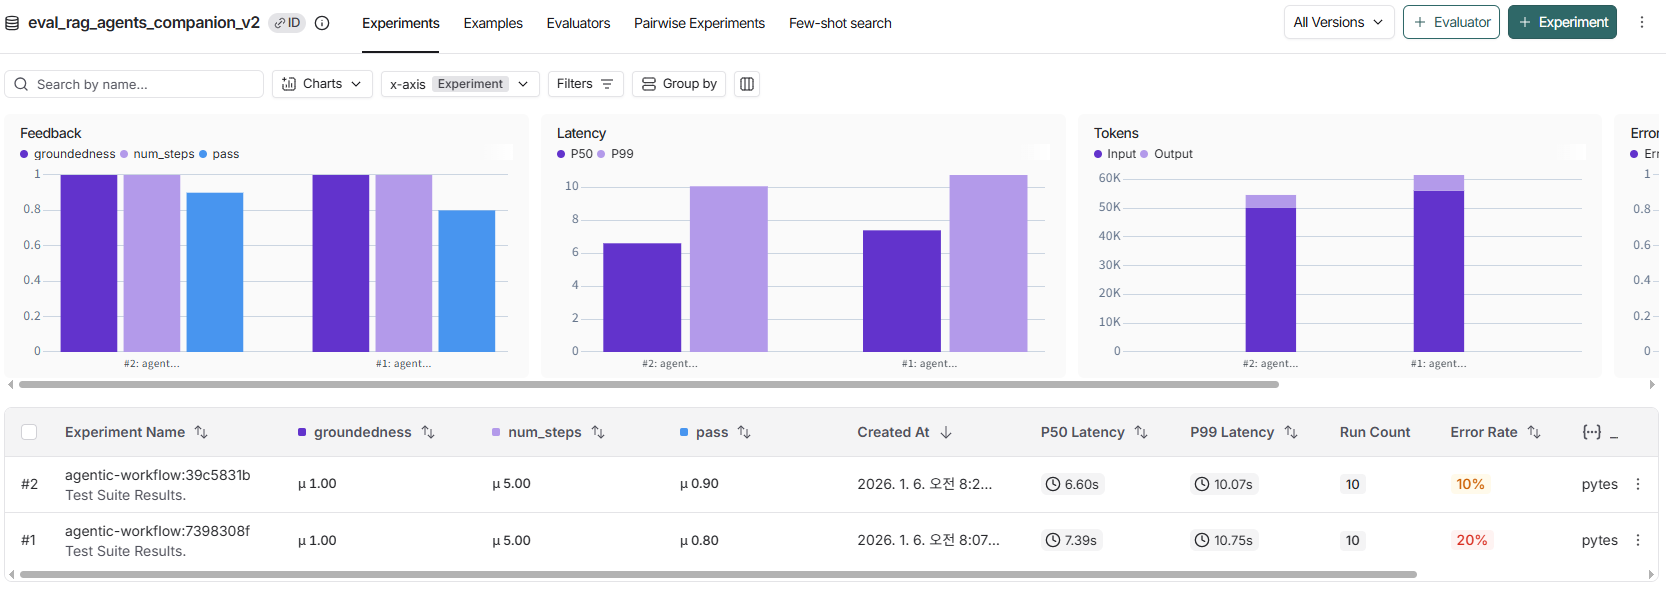